# 4 · Multivariate MMAR with Hurst memory

The preceding notebook added cross-asset dependence but kept its innovation driver independent through time. This final notebook adds one Hurst coefficient $H_i$ per asset—three new parameters, taking the joint estimator from 13 to 16, while retaining the same drift, cascade, Student-$t$, and correlation layers. We test whether the new signed-memory parameters are recoverable and whether they add information beyond cascade intermittency $q_i$.

In [1]:
from pathlib import Path

import bayesflow as bf

from mmar import hurst as model, viz
from mmar.data import load_market_returns
from mmar.viz import multivariate as plots

INFO:bayesflow:Multiple Keras-compatible backends detected (JAX, PyTorch, TensorFlow). Defaulting to JAX.
To override, set the KERAS_BACKEND environment variable before importing bayesflow.
See: https://keras.io/getting_started/#configuring-your-backend


INFO:bayesflow:Using backend 'jax'


In [2]:
ASSETS = model.ASSET_NAMES
FIGURES_DIR = Path("figures/hurst")
CHECKPOINT_DIR = Path("checkpoints/hurst")

In [3]:
viz.configure_plot_style()

## 1. Model extension: fractional Gaussian drivers

For asset $i\in\{\mathrm{VOO},\mathrm{GLD},\mathrm{TLT}\}$ and day $t=1,\ldots,256$,

$$\mathbf r_t=\boldsymbol\mu+D_t\boldsymbol\varepsilon_t,\qquad
D_t=\operatorname{diag}_{i=1}^{3}\!\left(\bar\sigma_i\sqrt{\theta_{i,t}(q_i)}\right),$$
$$\boldsymbol\varepsilon_t=\mathbf z_t^{(\mathbf H)}\sqrt{(\nu-2)/U_t},\qquad
U_t\overset{\mathrm{iid}}{\sim}\chi^2_\nu.$$

Everything in $D_t$ is inherited from the multivariate notebook. Only the Gaussian driver changes. Starting from $\mathbf g_t\overset{\mathrm{iid}}{\sim}N_3(\mathbf0,I_3)$ with $LL^\top=R$, the Davies–Harte filter $\mathcal F_{H_i}$ produces an asset-specific unit-variance fractional-Gaussian driver,

$$z_{i,1:T}^{(H_i)}=\mathcal F_{H_i}[(L\mathbf g)_{i,1:2T}]_{1:T},\qquad T=256,$$

whose marginal autocorrelation is:

$$\gamma_{H_i}(k)=\tfrac12\left(|k+1|^{2H_i}-2|k|^{2H_i}+|k-1|^{2H_i}\right).$$

The Student-$t$ layer has not changed: integrating out the shared $U_t$ gives Student-$t$ marginals and contemporaneous multivariate Student-$t$ scale-mixture tails. When the $H_i$ differ, $R$ describes Gaussian coherence **before** the marginal filters, not the exact same-day return correlation. Because $U_t$ is independent across days, $\gamma_{H_i}(k)$ is the exact autocorrelation of $z_{i,t}^{(H_i)}$, and nonzero-lag correlation in the final $\varepsilon_{i,t}$ is attenuated by the positive radial scale. Its sign and long-memory pattern are unchanged.

Thus $q_i$ and $H_i$ have distinct roles: $q_i$ controls **unsigned volatility intermittency**, whereas $H_i$ controls **signed dependence** in the Gaussian driver.

- $H_i=0.5$: asset $i$ has a white Gaussian driver; setting all three $H_i$ to $0.5$ recovers the baseline joint model in distribution.
- $H_i>0.5$: persistent driver; same-sign movements are favored.
- $H_i<0.5$: anti-persistent driver; sign reversals are favored.

### $H$ in motion

The animation holds the entire Gaussian seed fixed while $H$ moves from $0.35$ to $0.75$ and back. It isolates $z_t^{(H)}$: the cascade and Student-$t$ radial scale are omitted. The partial sum is a dependence diagnostic, not a return, price, or wealth path.

![A matched fractional-Gaussian driver transitions from anti-persistence through white noise to persistence as the Hurst coefficient increases.](gifs/hurst_memory.gif)

Regenerate with `python -m mmar.viz.hurst`.

In [4]:
model.prior_table()

,prior,meaning
parameter,,
mu[VOO],"Normal(0, 0.0015²)",VOO daily drift
sigma_bar[VOO],"Uniform(0.005, 0.025)",VOO baseline RMS return scale
q[VOO],"Uniform(0.52, 0.9)",VOO cascade contrast and volatility intermittency
mu[GLD],"Normal(0, 0.0015²)",GLD daily drift
sigma_bar[GLD],"Uniform(0.005, 0.025)",GLD baseline RMS return scale
q[GLD],"Uniform(0.52, 0.9)",GLD cascade contrast and volatility intermittency
mu[TLT],"Normal(0, 0.0015²)",TLT daily drift
sigma_bar[TLT],"Uniform(0.005, 0.025)",TLT baseline RMS return scale
q[TLT],"Uniform(0.52, 0.9)",TLT cascade contrast and volatility intermittency


### Does this make economic sense?

Signed daily returns are often close to serially uncorrelated, while absolute returns remain dependent; the MMAR cascade already targets that volatility persistence ([Ding, Granger, and Engle, 1993](https://doi.org/10.1016/0927-5398(93)90006-D); [Calvet and Fisher, 2002](https://doi.org/10.1162/003465302320259420)). If the cascade is sufficient, $H_i$ should remain near $0.5$. A shifted $H_i$ indicates additional directional dependence, while posterior dependence between $q_i$ and $H_i$ reveals whether the model can separate the two mechanisms.

## 2. Extending the neural estimator from 13 to 16 parameters

Only $H_{\mathrm{VOO}},H_{\mathrm{GLD}},H_{\mathrm{TLT}}\sim\operatorname{Uniform}(0.35,0.75)$ are new. The prior, adapter, and network otherwise follow the 13-parameter joint model.

In [ ]:
sigma_keys = tuple(f"sigma_bar_{asset}" for asset in ASSETS)
q_keys = tuple(f"q_{asset}" for asset in ASSETS)
hurst_keys = tuple(f"hurst_{asset}" for asset in ASSETS)

adapter = (
    bf.Adapter()
    .split("sigma_bar", into=sigma_keys)
    .split("q", into=q_keys)
    .split("hurst", into=hurst_keys)
)
for key, low, high in zip(sigma_keys, model.PRIOR.base.sigma_bar_low, model.PRIOR.base.sigma_bar_high):
    adapter.constrain(key, lower=low, upper=high)
for key, low, high in zip(q_keys, model.PRIOR.base.q_low, model.PRIOR.base.q_high):
    adapter.constrain(key, lower=low, upper=high)
for key in hurst_keys:
    adapter.constrain(key, lower=model.PRIOR.hurst_low, upper=model.PRIOR.hurst_high)

adapter = (
    adapter
    .constrain("nu", lower=model.PRIOR.base.nu_low, upper=model.PRIOR.base.nu_high)
    .constrain("correlation_partials", lower=-1.0, upper=1.0)
    .concatenate(
        ("mu", *sigma_keys, *q_keys, "nu", "correlation_partials", *hurst_keys),
        into="inference_variables",
    )
    .rename("returns", "summary_variables")
)

workflow = bf.BasicWorkflow(
    adapter=adapter,
    summary_network=bf.networks.FusionTransformer(summary_dim=32),
    inference_network=bf.networks.CouplingFlow(transform="spline", depth=4),
    standardize="all",
    checkpoint_filepath=CHECKPOINT_DIR,
    save_best_only=True
)

Existing checkpoints are not automatically loaded. Upon refitting, the checkpoints will be overwritten.
To restore the approximator from the checkpoint, call workflow.load_approximator() or pass restore=True to the workflow constructor.


## 3. Training and recovery

The training cell draws 100,000 simulations through `model.simulate` and fits for 100 epochs. Skip it and run the restore cell when using the saved checkpoint. Recovery on fresh simulations checks whether the added $H_i$ coordinates remain identifiable alongside the original 13 parameters.

In [ ]:
training_simulations = model.simulate(100_000, seed=42)
validation_simulations = model.simulate(600, seed=43)

history = workflow.fit_offline(
    data=training_simulations, validation_data=validation_simulations, epochs=100, batch_size=128
)

In [ ]:
workflow.load_approximator()

INFO:bayesflow:Approximator restored from 'checkpoints/hurst/model.keras'.


In [7]:
test_simulations = model.simulate(160, seed=555)
targets = model.stack_parameters(test_simulations)

estimates = model.stack_parameters(
    workflow.sample(conditions=test_simulations, num_samples=512, batch_size=40)
)

Summarizing:   0%|          | 0/4 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/4 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 5.17 seconds.


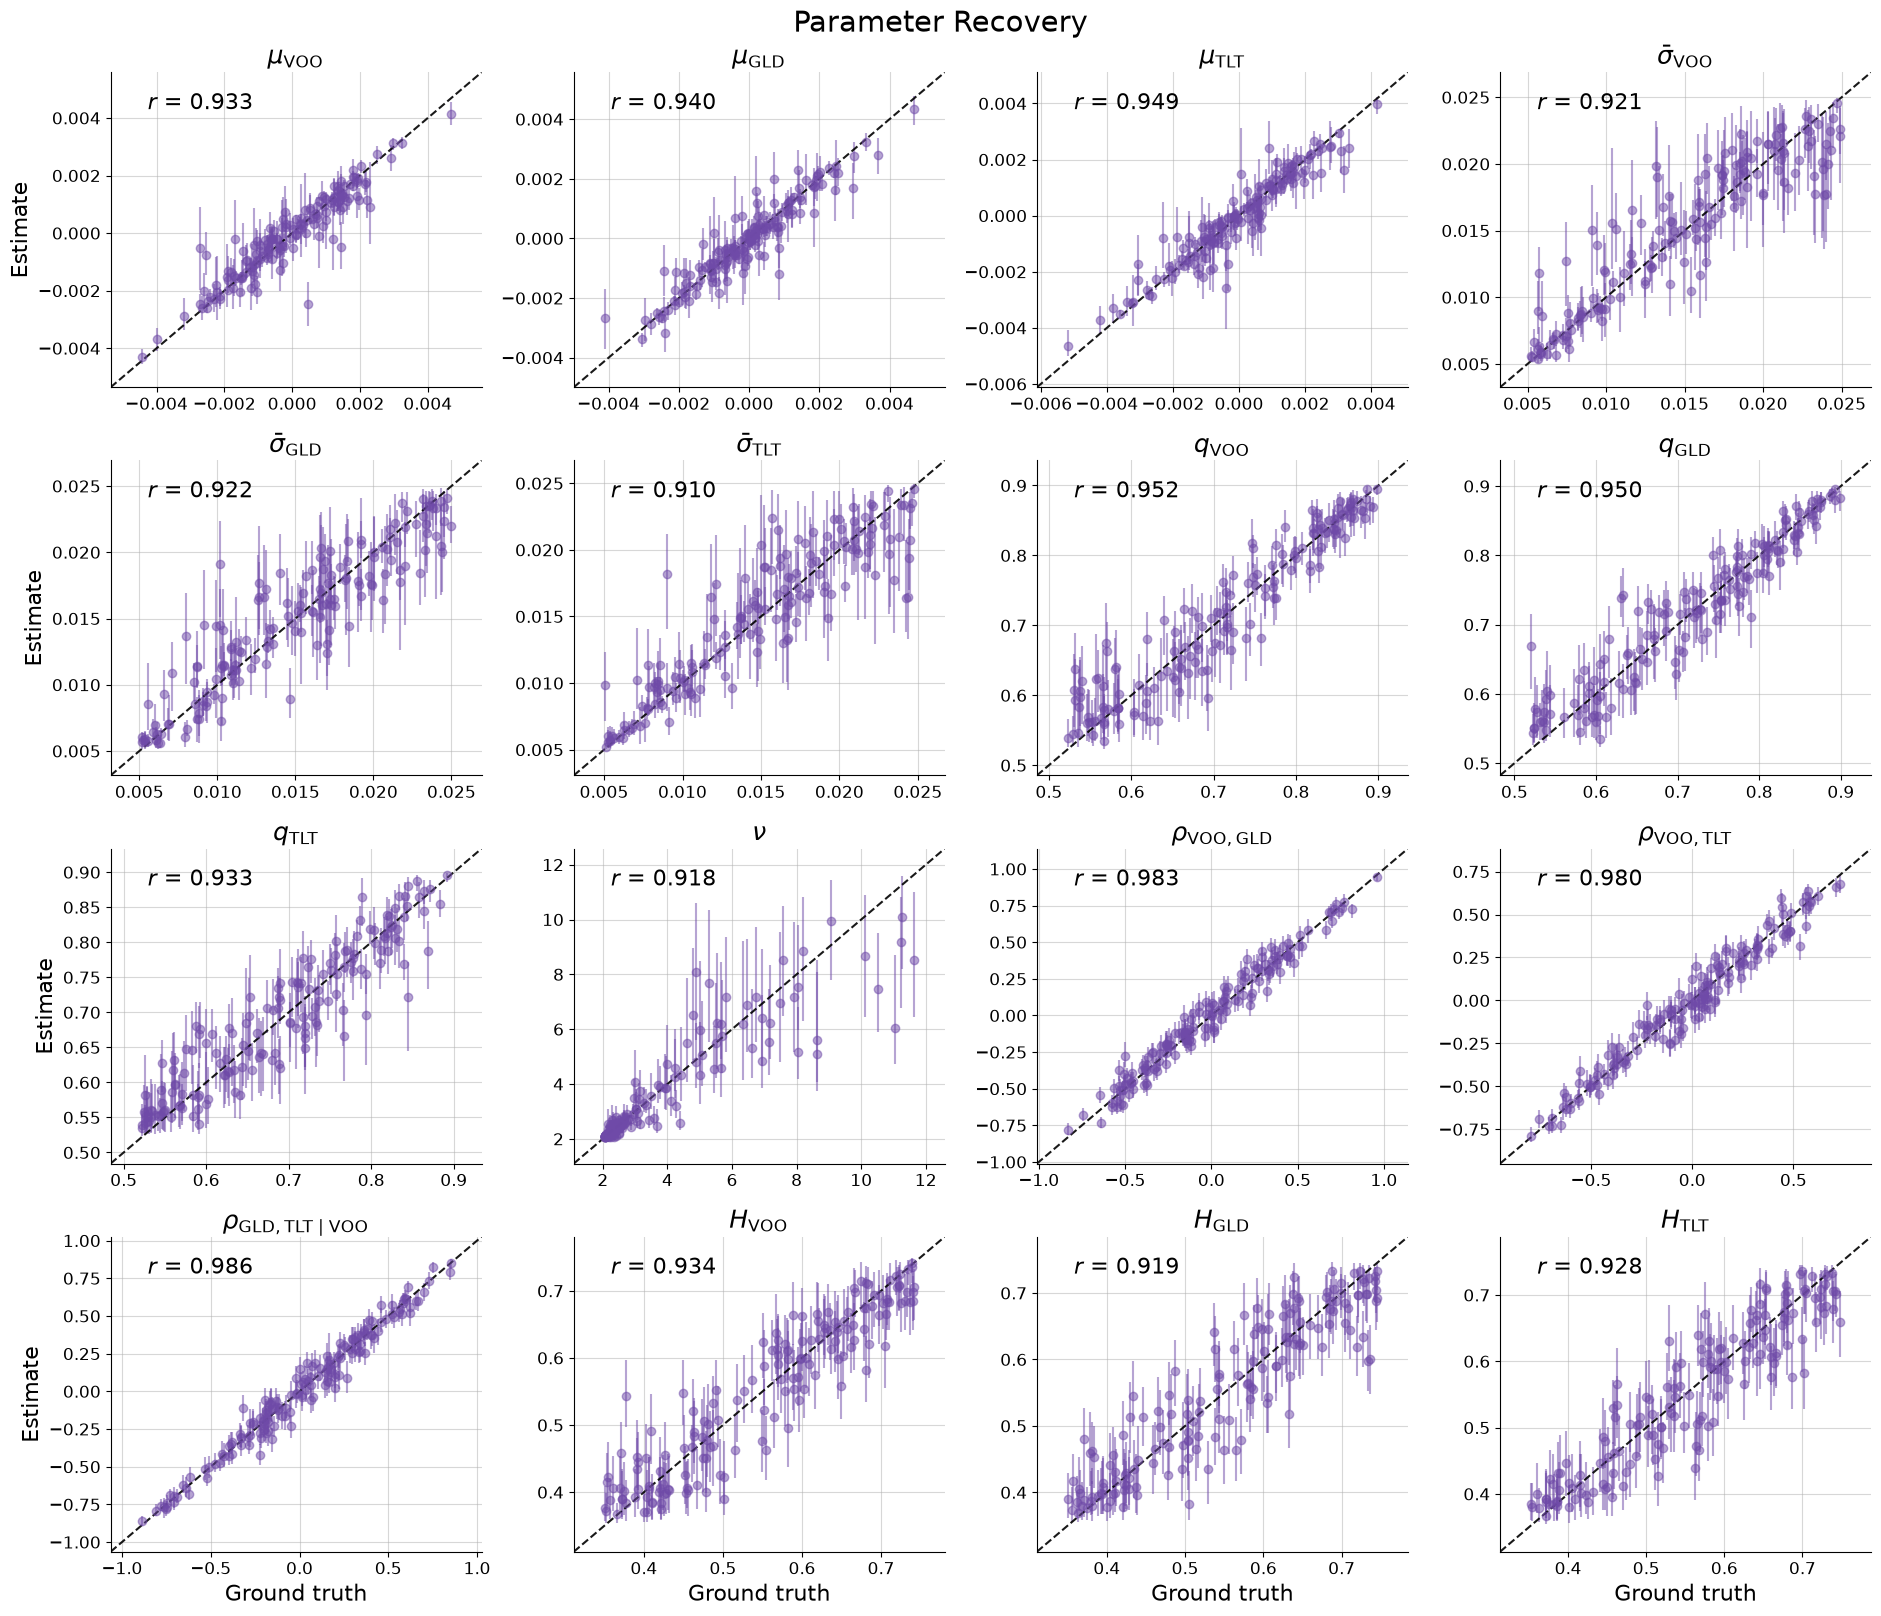

In [8]:
fig = viz.plot_recovery(
    estimates, targets, model.PARAMETER_LABELS, grid=(4, 4), interval=0.68
)
_ = viz.save_figure(fig, "01_parameter_recovery.png", FIGURES_DIR)

Recovery of all three Hurst coordinates alongside the $q_i$ parameters establishes **identifiability under the assumed model**: the 16-dimensional amortizer can distinguish them under idealized conditions. Of course, this does not establish that fractional signed memory is needed for market data; the observed posterior below addresses that narrower question.

## 4. Posterior predictive checks

The latest joint VOO–GLD–TLT window is inferred once, then replicated with its full posterior, including the three $H_i$. These generic checks ensure that adding memory does not damage the model's drawdown, wealth, or marginal-return fit; the next section examines the new memory coordinates directly.

In [ ]:
observed = load_market_returns(
    ASSETS, start="2015-01-01", end="2026-09-01"
).tail(model.WINDOW)

posterior = model.stack_parameters(
    workflow.sample(
        conditions={"returns": observed.to_numpy()[None, ...]},
        num_samples=2_000, batch_size=100, seed=46
    )
)[0]

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 3.07 seconds.


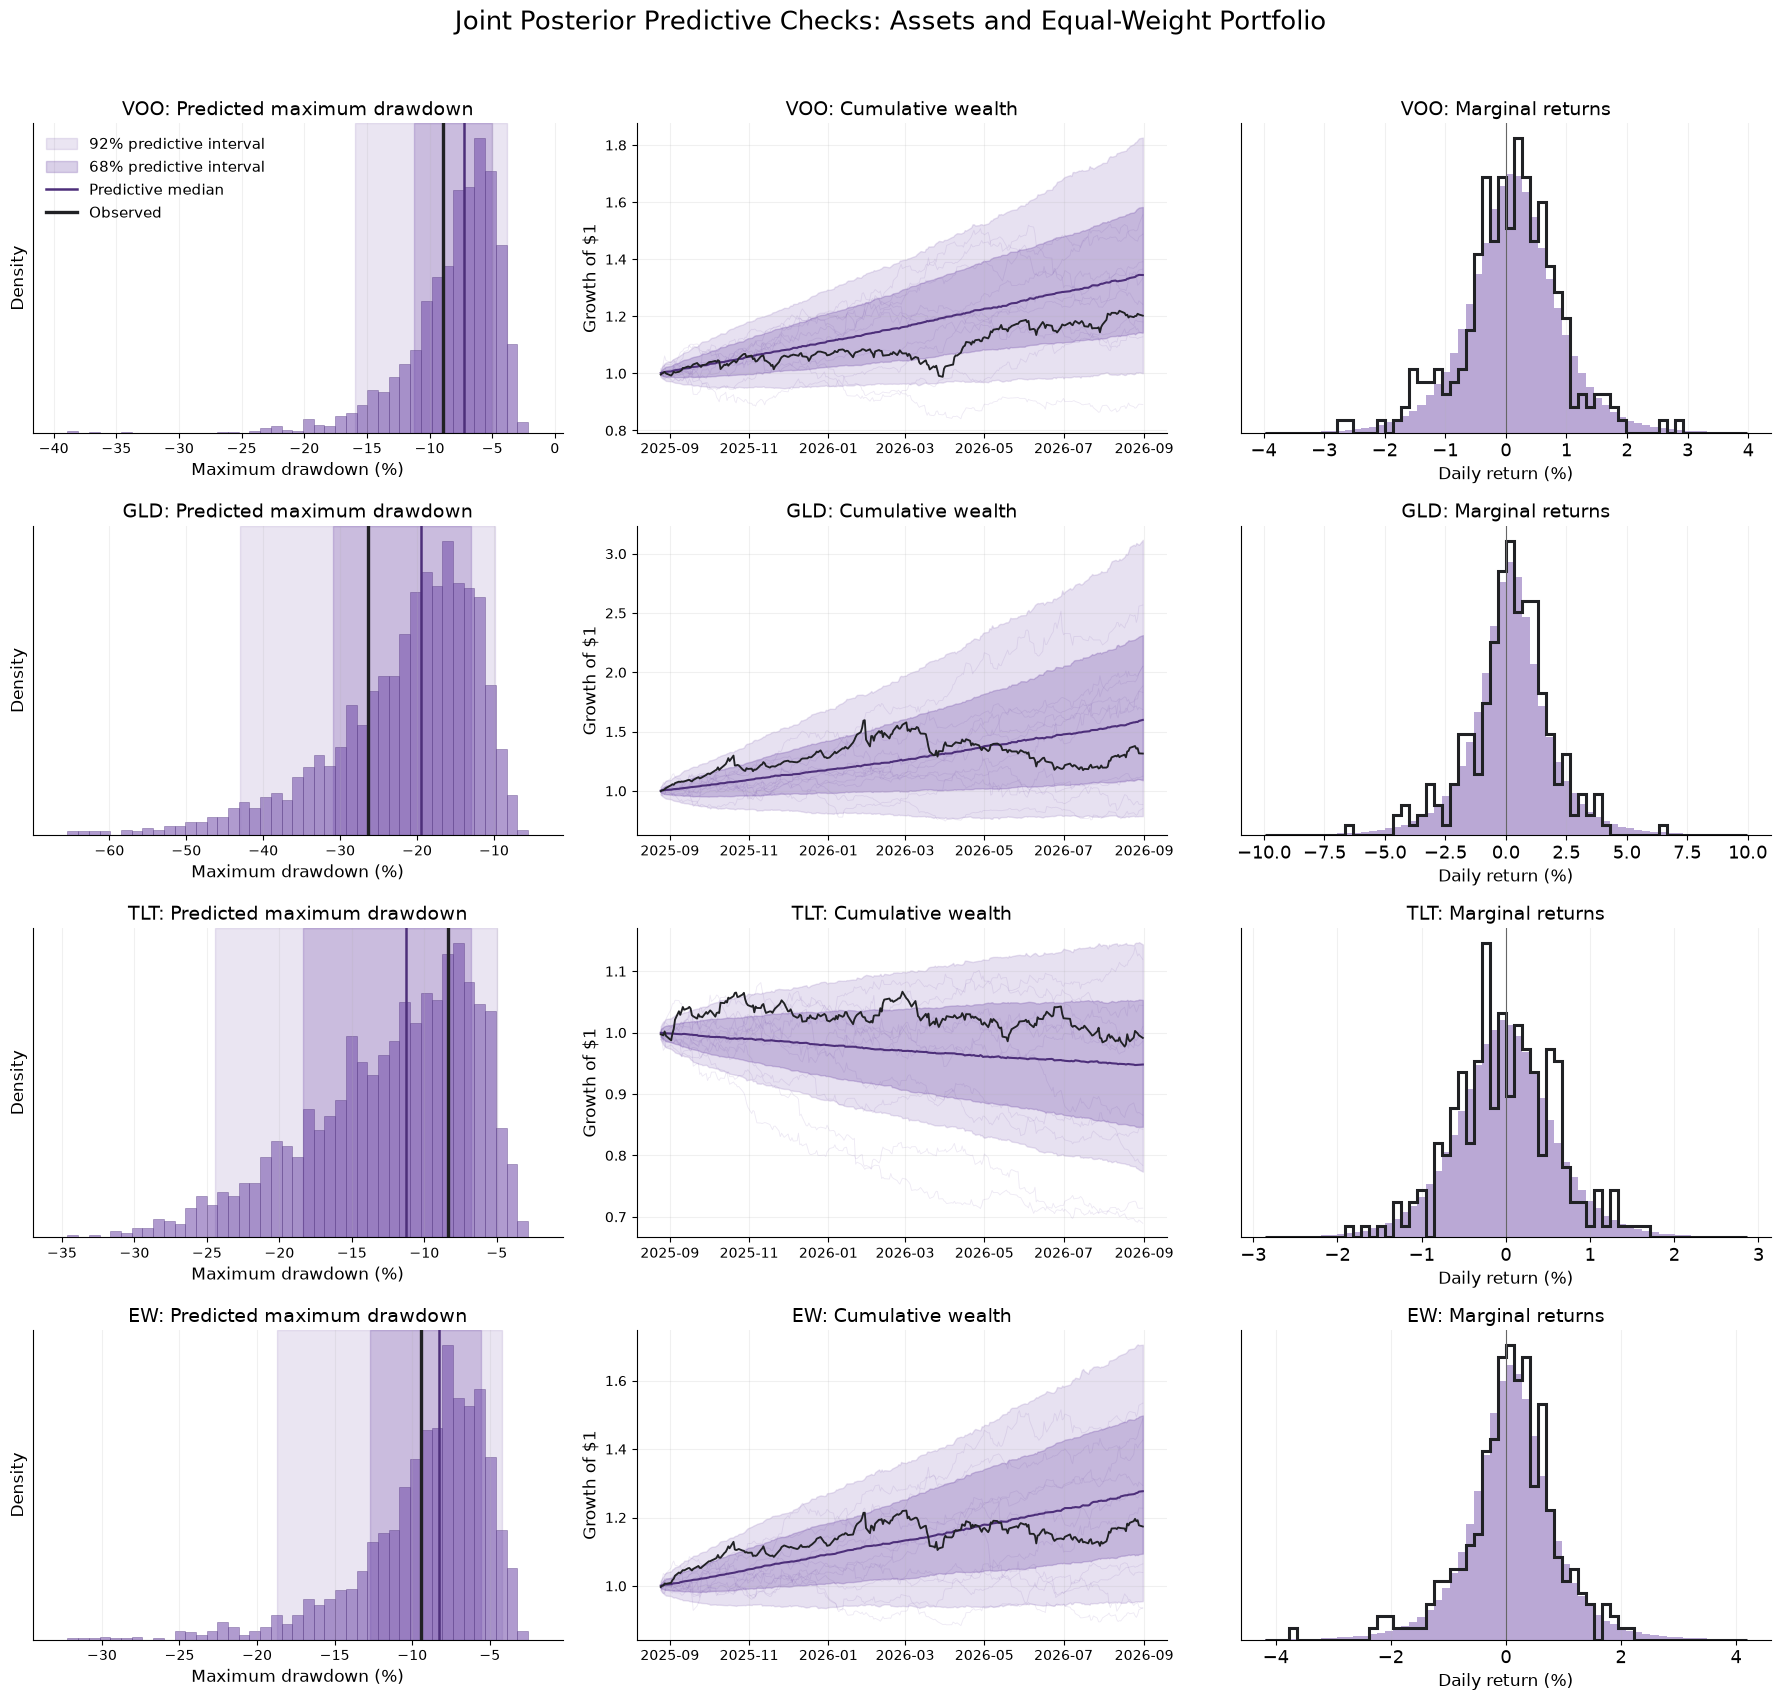

In [10]:
posterior_paths = model.posterior_resimulations(posterior, seed=47)
fig = plots.plot_multivariate_posterior_predictive_checks(posterior_paths, observed)
_ = viz.save_figure(fig, "02_posterior_predictive_checks.png", FIGURES_DIR)

## 5. What do $q$ and $H$ say about the three ETFs?

A useful separation test is whether the posterior can distinguish cascade intermittency ($q$) from signed-return memory ($H$). The table reports 92% equal-tailed intervals, $P(H>0.5)$, and the within-asset posterior correlation between $q_i$ and $H_i$.

In [11]:
model.style_q_hurst_posterior_summary(
    posterior,
    index_name=f"ETF ({observed.index[0].date()} to {observed.index[-1].date()})",
)

,$q$ median,$q$ 92% ETI,$H$ median,$H$ 92% ETI,$P(H>0.5)$,"$\operatorname{corr}(q,H)$"
ETF (2025-08-25 to 2026-08-31),,,,,,
VOO,0.615,"[0.532, 0.681]",0.484,"[0.405, 0.568]",34.3%,-0.03
GLD,0.719,"[0.666, 0.765]",0.514,"[0.428, 0.598]",61.3%,-0.03
TLT,0.545,"[0.522, 0.610]",0.431,"[0.364, 0.510]",6.6%,+0.01


### Joint Hurst posterior

Diagonal panels compare each marginal posterior with its $\operatorname{Uniform}(0.35,0.75)$ prior: contraction or displacement indicates information in the observed window. Off-diagonal tilt or ridges indicate posterior dependence among assets; axis alignment only indicates weak coupling, not identification. Simulation recovery above—not pair-plot geometry—establishes model-conditional identifiability. BayesFlow exposes this diagnostic as `bf.diagnostics.pairs_posterior`.

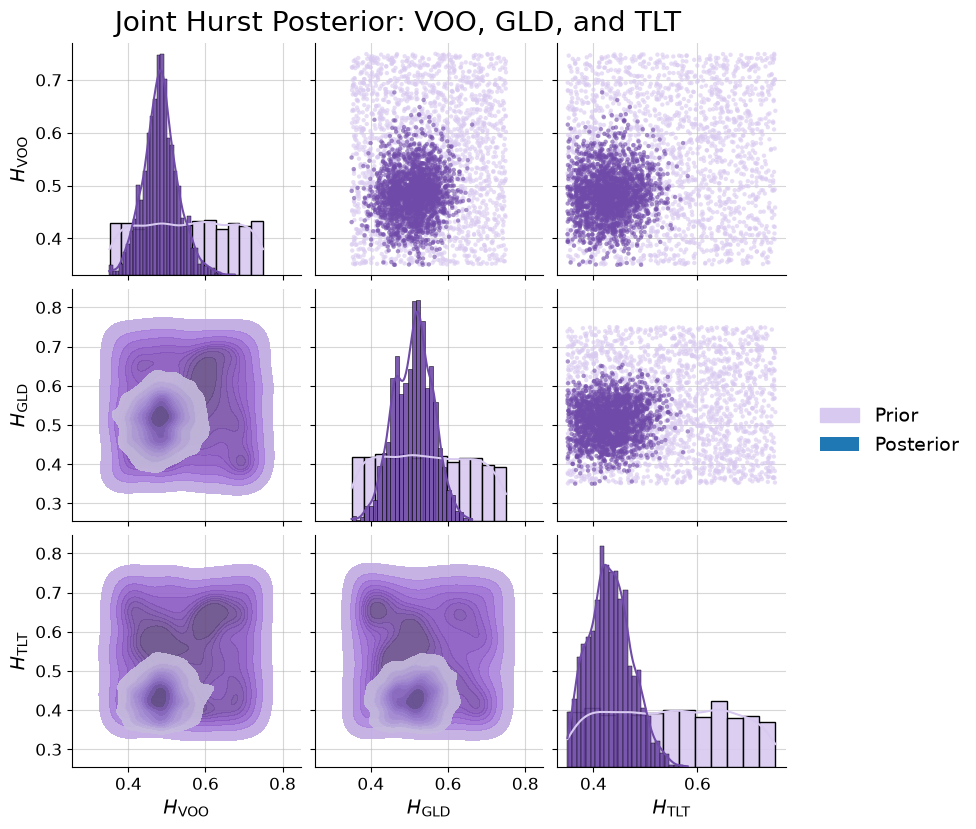

In [ ]:
hurst_posterior = model.q_hurst_posterior_draws(posterior)[1]
prior_hurst = model.simulate(2_000, seed=20260907)["hurst"]

pair_grid = bf.diagnostics.pairs_posterior(
    estimates=hurst_posterior,
    priors=prior_hurst,
    variable_names=model.PARAMETER_LABELS[-len(ASSETS):],
    height=2.7,
    post_color=viz.PREDICTION_PURPLE,
    prior_color=viz.PREDICTION_PURPLE_LIGHT,
    markersize=10,
)
legend = pair_grid.figure.legends[0]
for handle, color in zip(
    legend.legend_handles, (viz.PREDICTION_PURPLE_LIGHT, viz.PREDICTION_PURPLE)
):
    handle.set_facecolor(color)
    handle.set_edgecolor(color)
pair_grid.figure.suptitle("Joint Hurst Posterior: VOO, GLD, and TLT", fontsize=20, y=1.02)
_ = viz.save_figure(pair_grid.figure, "03_hurst_joint_posterior.png", FIGURES_DIR)

### Interpretation

For the displayed cached 256-day window, the posterior mostly separates the two kinds of dependence:

- **GLD has the strongest volatility intermittency** ($q\approx0.72$), but $H\approx0.51$ and only about 60% posterior probability of persistence. Thus, volatility in that period clusters, but its innovation does not show persuasive directional memory.
- **VOO is intermediate in cascade strength** ($q\approx0.62$), while $H\approx0.48$ remains compatible with $0.5$. Again, the model attributes most dependence to the volatility clock rather than to return direction.
- **TLT is the interesting exception.** Its $q\approx0.54$ is pressed toward the prior's lower boundary ($0.52$), so it has the weakest cascade intermittency permitted by our prior. Meanwhile $H\approx0.43$ and $P(H>0.5)\approx7\%$, consistent with an anti-persistent innovation.

The pair plot shows little cross-asset coupling among the $H_i$, while the near-zero within-asset $q$-$H$ correlations show little posterior trade-off in this window.

## 6. Synposis

The final extension combines the fractal cascade and Student-$t$ shocks with persistence. In this window, $q$ carries most of the volatility dependence for VOO and GLD. TLT provides modest evidence for directional reversal, but that conclusion remains model-, prior-, and window-dependent.